# Stoichiometry sweep — MLIP formation energy hull

Systematically sweep compositions across a binary chemical system, relax
each candidate with CHGNet, compute formation energies, and plot the
predicted convex hull.

**Workflow:**
1. Relax elemental endpoint structures to get MLIP reference energies.
2. Generate candidate structures at each stoichiometry from common crystal prototypes.
3. Relax all candidates with CHGNet.
4. Compute formation energy per atom relative to the elemental endpoints.
5. Plot the MLIP convex hull.

MLIP energies are screening predictions — they prioritise candidates for
DFT validation but do **not** prove thermodynamic stability.

In [15]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymatgen.core import Composition, Lattice, Structure


REPO = Path.cwd().resolve()
if not (REPO / "data").is_dir() and (REPO.parent / "data").is_dir():
    REPO = REPO.parent
if not (REPO / "data").is_dir():
    raise FileNotFoundError(
        f"Expected data/ under {REPO}. Open the notebook from the repo root."
    )

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

print("REPO =", REPO)

REPO = /home/hhoechter/projects/hullgap


## 1. Configuration

In [16]:
# --- Chemical system ---
ELEMENT_A = "Co"
ELEMENT_B = "Bi"
SYSTEM = f"{ELEMENT_A}-{ELEMENT_B}"

# --- MLIP settings ---
MODEL = "chgnet"       # "chgnet" or "mace"
FMAX = 0.05            # eV/\u00c5
MAX_STEPS = 300

# --- Paths ---
RESULTS_DIR = REPO / "data/results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"System:  {SYSTEM}")
print(f"Model:   {MODEL}")
print(f"fmax:    {FMAX} eV/\u00c5")
print(f"Steps:   {MAX_STEPS}")

System:  Co-Bi
Model:   chgnet
fmax:    0.05 eV/Å
Steps:   300


## 2. Load MLIP calculator

In [17]:
from hullgap.calculators import get_calculator

calc = get_calculator(MODEL)
print(f"{MODEL} calculator ready.")

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
chgnet calculator ready.


## 3. Elemental reference energies

Relax the ground-state elemental structures to get the MLIP energy per atom
for pure Co and pure Bi. These anchor the formation energy at zero for both
endpoints.

In [18]:
from ase.filters import FrechetCellFilter
from ase.optimize import LBFGS
from pymatgen.io.ase import AseAtomsAdaptor

# Ground-state elemental structures
ELEMENTAL_STRUCTURES = {
    "Co": Structure(
        Lattice.hexagonal(2.507, 4.069),
        ["Co", "Co"],
        [[1/3, 2/3, 1/4], [2/3, 1/3, 3/4]],
    ),
    "Bi": Structure(
        Lattice.rhombohedral(4.746, 57.23),
        ["Bi", "Bi"],
        [[0.234, 0.234, 0.234], [0.766, 0.766, 0.766]],
    ),
}


def relax_and_get_energy_per_atom(struct, calc, fmax=0.02, max_steps=500):
    """Relax a structure and return its MLIP energy per atom."""
    atoms = AseAtomsAdaptor.get_atoms(struct)
    atoms.calc = calc
    opt = LBFGS(FrechetCellFilter(atoms), logfile=None)
    opt.run(fmax=fmax, steps=max_steps)
    return atoms.get_potential_energy() / len(atoms)


refs = {}
for el, struct in ELEMENTAL_STRUCTURES.items():
    e_per_atom = relax_and_get_energy_per_atom(struct, calc)
    refs[el] = e_per_atom
    print(f"  {el:3s}  E/atom = {e_per_atom:.4f} eV")

print(f"\nReference energies: {refs}")

  Co   E/atom = -7.0292 eV
  Bi   E/atom = -3.8241 eV

Reference energies: {'Co': np.float32(-7.0292006), 'Bi': np.float32(-3.8241088)}


## 4. Generate candidate structures

For each stoichiometry, we build structures from common crystal prototypes.
The lattice parameter is estimated from metallic radii and scaled by the
prototype packing factor.

This is prototype *substitution*, not a generative model — it's fast and
good enough for a first MLIP screening pass.

In [19]:
# Metallic radii in Angstroms (used for lattice parameter estimation)
RADII = {"Co": 1.25, "Bi": 1.55}


def avg_radius(species_list):
    return np.mean([RADII[s] for s in species_list])


def make_candidates(el_a, el_b):
    """Generate candidate structures across the full composition range."""
    r_avg = avg_radius([el_a, el_b])
    candidates = []

    # --- AB (1:1) prototypes ---

    # CsCl (B2)
    a = 2 * r_avg / np.sqrt(3) * 2
    candidates.append(("CsCl_B2", Structure(
        Lattice.cubic(a),
        [el_a, el_b],
        [[0, 0, 0], [0.5, 0.5, 0.5]],
    )))

    # NaCl (B1)
    a = 2 * r_avg * np.sqrt(2)
    candidates.append(("NaCl_B1", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.5, 0, 0], [0, 0.5, 0], [0, 0, 0.5], [0.5, 0.5, 0.5],
        ],
    )))

    # ZnS zincblende (B3)
    a = 4 * r_avg / np.sqrt(3)
    candidates.append(("ZnS_B3", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
        ],
    )))

    # NiAs (B8_1) — hexagonal
    a_hex = 2 * r_avg
    c_hex = a_hex * 1.63
    candidates.append(("NiAs_B81", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a, el_a, el_b, el_b],
        [
            [0, 0, 0], [0, 0, 0.5],
            [1/3, 2/3, 0.25], [2/3, 1/3, 0.75],
        ],
    )))

    # FeSi (B20) — cubic
    a = 2 * r_avg * 2.1
    candidates.append(("FeSi_B20", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0.137, 0.137, 0.137], [0.637, 0.363, 0.863],
            [0.363, 0.863, 0.637], [0.863, 0.637, 0.363],
            [0.845, 0.845, 0.845], [0.345, 0.655, 0.155],
            [0.655, 0.155, 0.345], [0.155, 0.345, 0.655],
        ],
    )))

    # --- A3B (3:1) prototypes ---

    # Cu3Au (L1_2)
    a = 2 * r_avg * np.sqrt(2)
    candidates.append(("Cu3Au_L12", Structure(
        Lattice.cubic(a),
        [el_a]*3 + [el_b],
        [[0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5], [0, 0, 0]],
    )))

    # Ni3Sn (D0_19) — hexagonal
    a_hex = 2 * r_avg * 2
    c_hex = a_hex * 0.82
    candidates.append(("Ni3Sn_D019", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a]*6 + [el_b]*2,
        [
            [5/6, 2/3, 1/4], [1/6, 1/3, 3/4],
            [1/3, 1/3, 1/4], [2/3, 2/3, 3/4],
            [1/2, 0, 1/4], [1/2, 0, 3/4],
            [0, 0, 1/4], [0, 0, 3/4],
        ],
    )))

    # --- AB3 (1:3) — same prototypes, elements swapped ---

    candidates.append(("Au3Cu_L12", Structure(
        Lattice.cubic(a),
        [el_b]*3 + [el_a],
        [[0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5], [0, 0, 0]],
    )))

    candidates.append(("Sn3Ni_D019", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_b]*6 + [el_a]*2,
        [
            [5/6, 2/3, 1/4], [1/6, 1/3, 3/4],
            [1/3, 1/3, 1/4], [2/3, 2/3, 3/4],
            [1/2, 0, 1/4], [1/2, 0, 3/4],
            [0, 0, 1/4], [0, 0, 3/4],
        ],
    )))

    # --- A2B (2:1) prototypes ---

    # MoSi2 (C11_b) — tetragonal
    a_tet = 2 * r_avg * 1.1
    c_tet = a_tet * 2.5
    candidates.append(("MoSi2_C11b", Structure(
        Lattice.tetragonal(a_tet, c_tet),
        [el_a]*2 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0.5],
            [0, 0, 1/3], [0, 0, 2/3],
            [0.5, 0.5, 1/3+0.5], [0.5, 0.5, 2/3-0.5],
        ],
    )))

    # CaF2 fluorite (C1)
    a = 2 * r_avg * np.sqrt(2) * 1.05
    candidates.append(("CaF2_C1", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*8,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
            [0.25, 0.25, 0.75], [0.75, 0.75, 0.75],
            [0.75, 0.25, 0.25], [0.25, 0.75, 0.25],
        ],
    )))

    # Inverse fluorite AB2 -> A2B swap
    candidates.append(("CaF2_C1_inv", Structure(
        Lattice.cubic(a),
        [el_b]*4 + [el_a]*8,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
            [0.25, 0.25, 0.75], [0.75, 0.75, 0.75],
            [0.75, 0.25, 0.25], [0.25, 0.75, 0.25],
        ],
    )))

    # --- A5B (5:1) ---

    # CaCu5 (D2_d) — hexagonal
    a_hex = 2 * r_avg * 1.8
    c_hex = a_hex * 0.8
    candidates.append(("CaCu5_D2d", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_b] + [el_a]*5,
        [
            [0, 0, 0],
            [1/3, 2/3, 0], [2/3, 1/3, 0],
            [0, 1/2, 1/2], [1/2, 0, 1/2], [1/2, 1/2, 1/2],
        ],
    )))

    # Inverse: A=B, B=A
    candidates.append(("CaCu5_D2d_inv", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a] + [el_b]*5,
        [
            [0, 0, 0],
            [1/3, 2/3, 0], [2/3, 1/3, 0],
            [0, 1/2, 1/2], [1/2, 0, 1/2], [1/2, 1/2, 1/2],
        ],
    )))

    return candidates


candidates = make_candidates(ELEMENT_A, ELEMENT_B)

print(f"{len(candidates)} candidate structures generated:\n")
print(f"{'Prototype':<20s} {'Formula':<12s} {'x_Bi':>6s}  {'Atoms':>5s}")
print("-" * 48)
for name, struct in candidates:
    formula = struct.composition.reduced_formula
    comp = struct.composition
    x_b = comp.get_atomic_fraction(ELEMENT_B)
    print(f"{name:<20s} {formula:<12s} {x_b:6.3f}  {len(struct):5d}")

14 candidate structures generated:

Prototype            Formula        x_Bi  Atoms
------------------------------------------------
CsCl_B2              CoBi          0.500      2
NaCl_B1              CoBi          0.500      8
ZnS_B3               CoBi          0.500      8
NiAs_B81             CoBi          0.500      4
FeSi_B20             CoBi          0.500      8
Cu3Au_L12            Co3Bi         0.250      4
Ni3Sn_D019           Co3Bi         0.250      8
Au3Cu_L12            CoBi3         0.750      4
Sn3Ni_D019           CoBi3         0.750      8
MoSi2_C11b           CoBi2         0.667      6
CaF2_C1              CoBi2         0.667     12
CaF2_C1_inv          Co2Bi         0.333     12
CaCu5_D2d            Co5Bi         0.167      6
CaCu5_D2d_inv        CoBi5         0.833      6


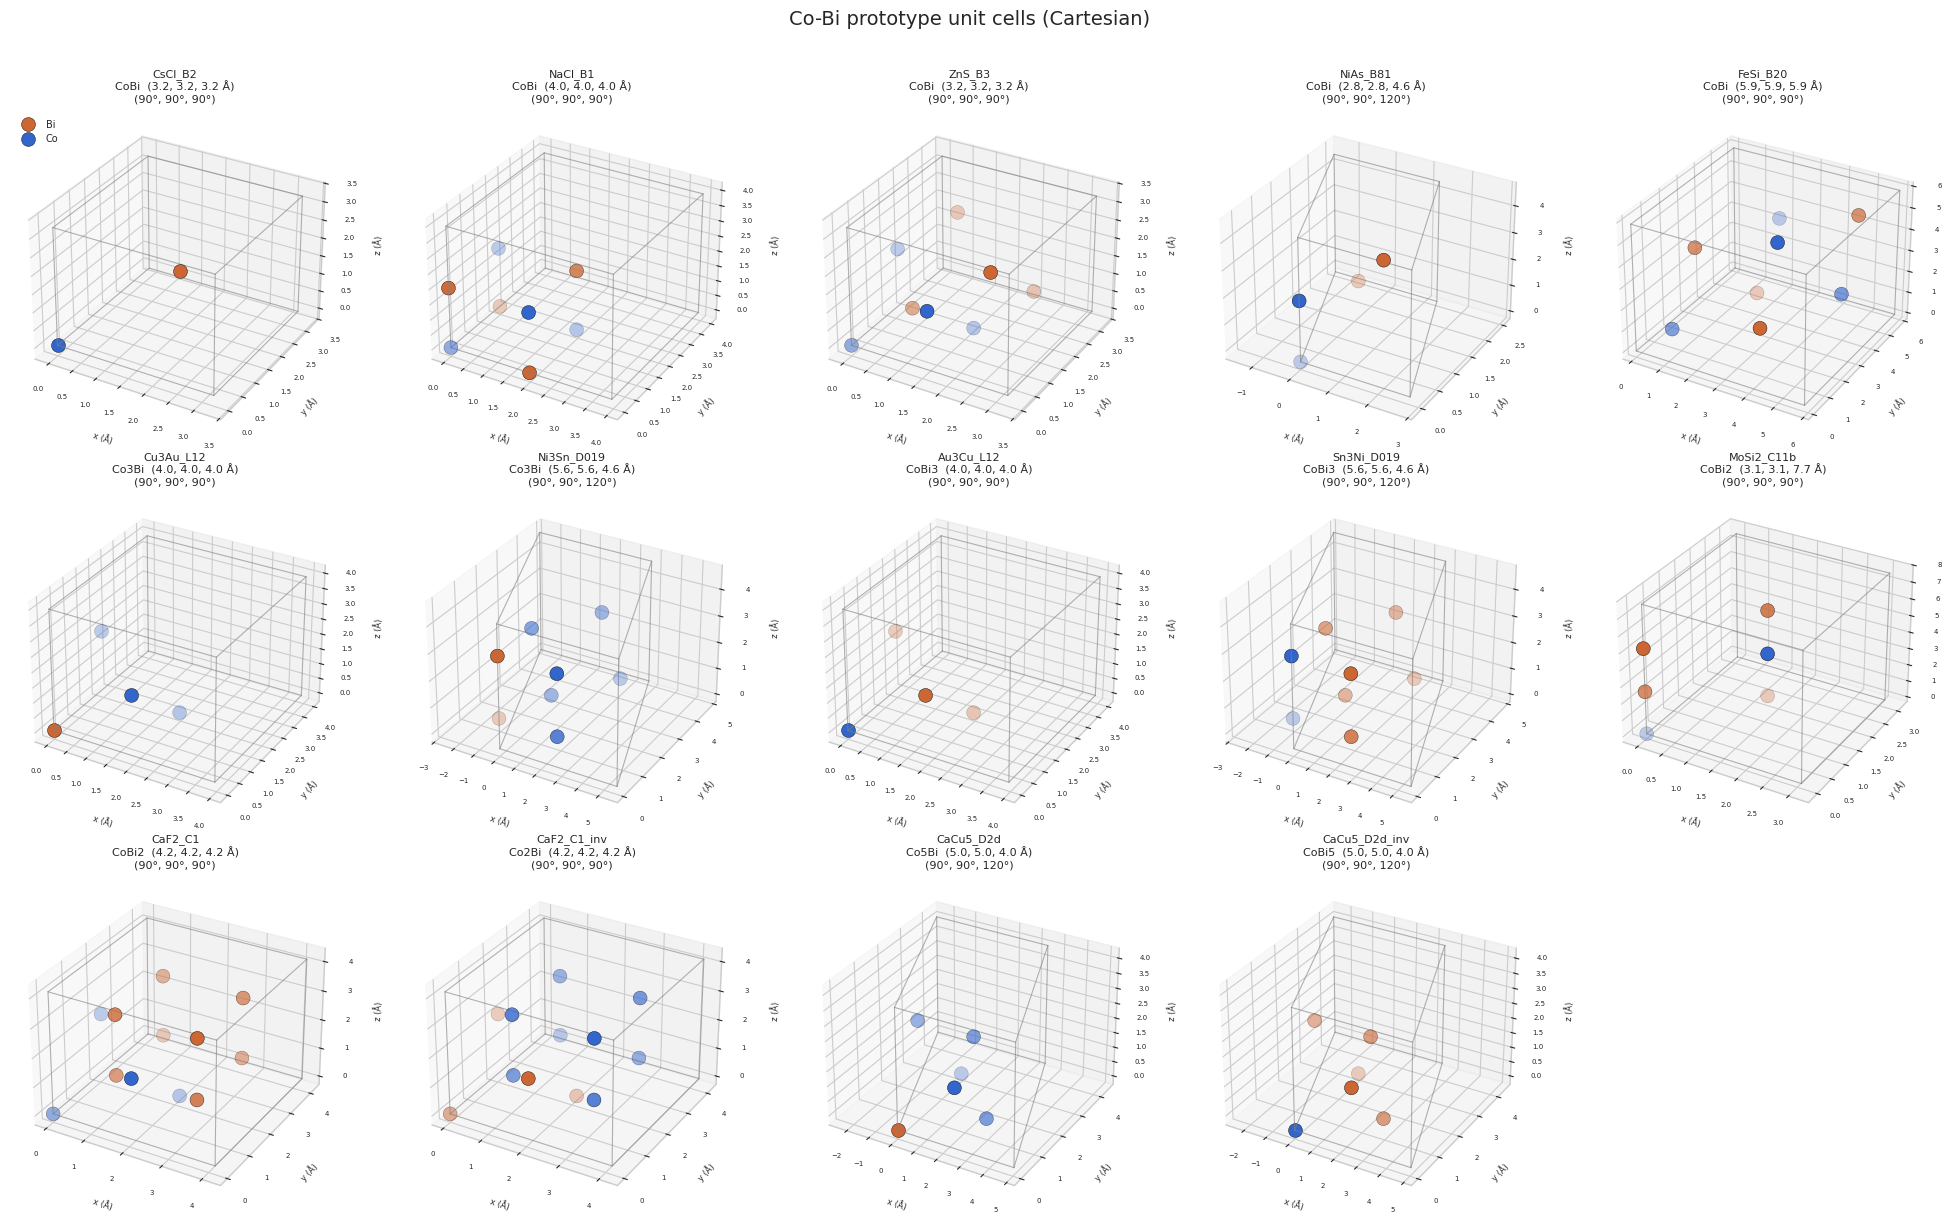

In [28]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from itertools import combinations

element_colors = {"Co": "#3366cc", "Bi": "#cc6633"}

n = len(candidates)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig = plt.figure(figsize=(4 * ncols, 4 * nrows))

for idx, (name, struct) in enumerate(candidates):
    ax = fig.add_subplot(nrows, ncols, idx + 1, projection="3d")
    lattice = struct.lattice.matrix  # 3x3, rows are lattice vectors
    cart_coords = struct.cart_coords
    species = [str(s.specie) for s in struct]

    for sym in sorted(set(species)):
        mask = np.array([s == sym for s in species])
        pts = cart_coords[mask]
        ax.scatter(
            pts[:, 0], pts[:, 1], pts[:, 2],
            s=100, label=sym,
            c=element_colors.get(sym, "#888888"),
            edgecolors="black", linewidths=0.3, depthshade=True,
        )

    # Draw unit cell edges from the 8 corners of the parallelepiped
    a, b, c = lattice[0], lattice[1], lattice[2]
    origin = np.zeros(3)
    corners_frac = np.array([
        [0,0,0],[1,0,0],[0,1,0],[0,0,1],
        [1,1,0],[1,0,1],[0,1,1],[1,1,1],
    ], dtype=float)
    corners = corners_frac @ lattice

    # Edges: connect corners that differ by exactly one lattice vector
    for i, j in combinations(range(8), 2):
        diff = corners_frac[i] - corners_frac[j]
        if np.count_nonzero(diff) == 1:
            ax.plot(
                [corners[i, 0], corners[j, 0]],
                [corners[i, 1], corners[j, 1]],
                [corners[i, 2], corners[j, 2]],
                color="gray", lw=0.8, alpha=0.6,
            )

    all_pts = np.vstack([cart_coords, corners])
    pad = 0.3
    for dim, lbl in enumerate(["x (Å)", "y (Å)", "z (Å)"]):
        lo, hi = all_pts[:, dim].min() - pad, all_pts[:, dim].max() + pad
        getattr(ax, f"set_{'xyz'[dim]}lim")(lo, hi)
        getattr(ax, f"set_{'xyz'[dim]}label")(lbl, fontsize=6)

    ax.tick_params(labelsize=5)
    cp = struct.lattice.parameters
    formula = struct.composition.reduced_formula
    ax.set_title(
        f"{name}\n{formula}  "
        f"({cp[0]:.1f}, {cp[1]:.1f}, {cp[2]:.1f} Å)\n"
        f"({cp[3]:.0f}°, {cp[4]:.0f}°, {cp[5]:.0f}°)",
        fontsize=8,
    )
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"{SYSTEM} prototype unit cells (Cartesian)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Relax all candidates

In [20]:
results = []

for i, (name, struct) in enumerate(candidates, 1):
    print(f"[{i}/{len(candidates)}] {name}", end=" … ", flush=True)
    atoms = AseAtomsAdaptor.get_atoms(struct)
    atoms.calc = calc
    formula = struct.composition.reduced_formula

    try:
        opt = LBFGS(FrechetCellFilter(atoms), logfile=None)
        converged = opt.run(fmax=FMAX, steps=MAX_STEPS)

        energy = atoms.get_potential_energy()
        forces = atoms.get_forces()
        fmax_val = float(np.max(np.linalg.norm(forces, axis=1)))
        n_atoms = len(atoms)
        volume = atoms.get_volume()
        cell = atoms.cell.cellpar()

        results.append({
            "prototype": name,
            "formula": formula,
            "n_atoms": n_atoms,
            "x_Bi": struct.composition.get_atomic_fraction(ELEMENT_B),
            "energy_total_eV": float(energy),
            "energy_per_atom_eV": float(energy) / n_atoms,
            "fmax_eV_A": fmax_val,
            "volume_per_atom_A3": volume / n_atoms,
            "a_A": cell[0], "b_A": cell[1], "c_A": cell[2],
            "status": "converged" if converged else "max_steps_reached",
            "n_steps": opt.nsteps,
            "error": "",
        })
        print(f"{formula}  E/atom={float(energy)/n_atoms:.4f} eV  steps={opt.nsteps}")
    except Exception as exc:
        results.append({
            "prototype": name,
            "formula": formula,
            "n_atoms": len(struct),
            "x_Bi": struct.composition.get_atomic_fraction(ELEMENT_B),
            "energy_total_eV": np.nan,
            "energy_per_atom_eV": np.nan,
            "fmax_eV_A": np.nan,
            "volume_per_atom_A3": np.nan,
            "a_A": np.nan, "b_A": np.nan, "c_A": np.nan,
            "status": "failed",
            "n_steps": 0,
            "error": str(exc),
        })
        print(f"FAILED: {exc}")

df = pd.DataFrame(results)
print(f"\n{(df['status'] != 'failed').sum()}/{len(df)} relaxations succeeded.")

[1/14] CsCl_B2 … CoBi  E/atom=-4.9626 eV  steps=3
[2/14] NaCl_B1 … 

Exception ignored in: <function tqdm.__del__ at 0x7f0c01a8e480>
Traceback (most recent call last):
  File "/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x7f0c01a8e480>
Traceback (most recent call last):
  File "/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x7f0c01

CoBi  E/atom=-0.3633 eV  steps=300
[3/14] ZnS_B3 … CoBi  E/atom=7.9754 eV  steps=5
[4/14] NiAs_B81 … CoBi  E/atom=-0.1847 eV  steps=300
[5/14] FeSi_B20 … CoBi  E/atom=-5.0459 eV  steps=18
[6/14] Cu3Au_L12 … Co3Bi  E/atom=-5.9263 eV  steps=4
[7/14] Ni3Sn_D019 … Co3Bi  E/atom=-6.0865 eV  steps=91
[8/14] Au3Cu_L12 … CoBi3  E/atom=-4.0790 eV  steps=6
[9/14] Sn3Ni_D019 … CoBi3  E/atom=-4.5827 eV  steps=75
[10/14] MoSi2_C11b … CoBi2  E/atom=-4.7434 eV  steps=25
[11/14] CaF2_C1 … CoBi2  E/atom=-2.4880 eV  steps=300
[12/14] CaF2_C1_inv … Co2Bi  E/atom=-5.7614 eV  steps=300
[13/14] CaCu5_D2d … Co5Bi  E/atom=-6.3193 eV  steps=8
[14/14] CaCu5_D2d_inv … CoBi5  E/atom=-4.1156 eV  steps=300

14/14 relaxations succeeded.


## 6. Compute formation energies

Formation energy per atom:

$$E_\mathrm{form} = \frac{E_\mathrm{total}(\mathrm{A}_x\mathrm{B}_y) - x\,\mu_\mathrm{A} - y\,\mu_\mathrm{B}}{x + y}$$

where $\mu_\mathrm{A}$ and $\mu_\mathrm{B}$ are the MLIP energies per atom of
the relaxed elemental endpoint structures.

In [21]:
def formation_energy(row, refs, el_a, el_b):
    """Formation energy per atom from the relaxation result row."""
    if np.isnan(row["energy_total_eV"]):
        return np.nan
    comp = Composition(row["formula"])
    amt_a = comp.get_atomic_fraction(el_a) * comp.num_atoms
    amt_b = comp.get_atomic_fraction(el_b) * comp.num_atoms
    e_ref = amt_a * refs[el_a] + amt_b * refs[el_b]
    return (row["energy_total_eV"] - e_ref) / comp.num_atoms


df["formation_energy_eV_atom"] = df.apply(
    formation_energy, axis=1, refs=refs, el_a=ELEMENT_A, el_b=ELEMENT_B
)

display_cols = [
    "prototype", "formula", "x_Bi",
    "energy_per_atom_eV", "formation_energy_eV_atom",
    "fmax_eV_A", "volume_per_atom_A3", "status",
]
df[display_cols].sort_values("x_Bi").style.format({
    "x_Bi": "{:.3f}",
    "energy_per_atom_eV": "{:.4f}",
    "formation_energy_eV_atom": "{:.4f}",
    "fmax_eV_A": "{:.2e}",
    "volume_per_atom_A3": "{:.2f}",
}).background_gradient(subset=["formation_energy_eV_atom"], cmap="RdYlGn_r")

,prototype,formula,x_Bi,energy_per_atom_eV,formation_energy_eV_atom,fmax_eV_A,volume_per_atom_A3,status
12,CaCu5_D2d,Co5Bi,0.167,-6.3193,0.1757,3.17e-03,13.85,converged
6,Ni3Sn_D019,Co3Bi,0.250,-6.0865,-5.9450,4.72e-02,15.01,converged
5,Cu3Au_L12,Co3Bi,0.250,-5.9263,0.3016,9.38e-06,14.14,converged
11,CaF2_C1_inv,Co2Bi,0.333,-5.7614,-17.0847,3.42e-02,17.07,max_steps_reached
3,NiAs_B81,CoBi,0.500,-0.1847,5.0572,1.49e+00,7.09,max_steps_reached
2,ZnS_B3,CoBi,0.500,7.9754,37.3284,9.33e-03,3.81,converged
0,CsCl_B2,CoBi,0.500,-4.9626,0.4641,5.58e-06,17.89,converged
1,NaCl_B1,CoBi,0.500,-0.3633,3.9734,3.18e-04,7.42,max_steps_reached
4,FeSi_B20,CoBi,0.500,-5.0459,-14.7571,2.26e-02,19.17,converged
10,CaF2_C1,CoBi2,0.667,-2.4880,-5.0597,1.53e+01,27.46,max_steps_reached


## 7. Build and plot the MLIP convex hull

In [22]:
from hullgap.dft.dft_hull import hull_energy_at_x, lower_convex_hull_2d

ok = df[df["status"] != "failed"].copy()

# Hull points: elemental endpoints at (0, 0) and (1, 0) plus all candidates
hull_pts = [(0.0, 0.0), (1.0, 0.0)]
for _, r in ok.iterrows():
    hull_pts.append((float(r["x_Bi"]), float(r["formation_energy_eV_atom"])))

hull_arr = lower_convex_hull_2d(np.array(hull_pts, dtype=float))

# Energy above hull for each candidate
ok["e_above_hull_eV_atom"] = ok.apply(
    lambda r: r["formation_energy_eV_atom"] - hull_energy_at_x(hull_arr, r["x_Bi"]),
    axis=1,
)


def _label(e_ah):
    if e_ah <= 0.001:
        return "on_hull"
    if e_ah <= 0.025:
        return "near_hull"
    if e_ah <= 0.100:
        return "metastable"
    return "unstable"


ok["stability_label"] = ok["e_above_hull_eV_atom"].apply(_label)

print("Stability summary:")
print(ok["stability_label"].value_counts().to_string())

Stability summary:
stability_label
unstable    12
on_hull      2


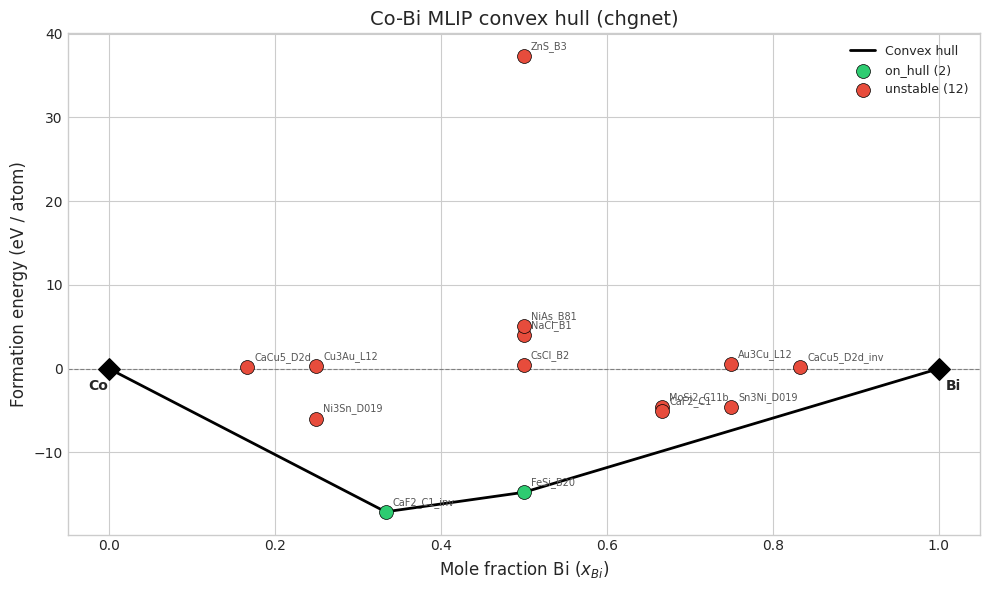

Saved to /home/hhoechter/projects/hullgap/reports/figures/Co-Bi_mlip_hull_chgnet.png


In [23]:
label_colors = {
    "on_hull": "#2ecc71",
    "near_hull": "#3498db",
    "metastable": "#e67e22",
    "unstable": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(10, 6))

# Hull line
xs_line = np.linspace(0, 1, 300)
ys_line = np.array([hull_energy_at_x(hull_arr, x) for x in xs_line])
ax.plot(xs_line, ys_line, "k-", lw=2, label="Convex hull", zorder=3)

# Candidate points
for label, color in label_colors.items():
    sub = ok[ok["stability_label"] == label]
    if sub.empty:
        continue
    ax.scatter(
        sub["x_Bi"], sub["formation_energy_eV_atom"],
        s=100, c=color, edgecolors="black", linewidths=0.5,
        label=f"{label} ({len(sub)})", zorder=4,
    )

# Label each point with prototype name
for _, r in ok.iterrows():
    ax.annotate(
        r["prototype"], (r["x_Bi"], r["formation_energy_eV_atom"]),
        textcoords="offset points", xytext=(5, 5), fontsize=7,
        color="#555",
    )

# Elemental endpoints
ax.scatter([0, 1], [0, 0], s=120, c="black", marker="D", zorder=5)
ax.annotate(ELEMENT_A, (0, 0), textcoords="offset points", xytext=(-15, -15), fontsize=10, fontweight="bold")
ax.annotate(ELEMENT_B, (1, 0), textcoords="offset points", xytext=(5, -15), fontsize=10, fontweight="bold")

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel(f"Mole fraction {ELEMENT_B} ($x_{{{ELEMENT_B}}}$)", fontsize=12)
ax.set_ylabel("Formation energy (eV / atom)", fontsize=12)
ax.set_title(f"{SYSTEM} MLIP convex hull ({MODEL})", fontsize=14)
ax.legend(loc="best", fontsize=9)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()

fig_path = REPO / f"reports/figures/{SYSTEM}_mlip_hull_{MODEL}.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {fig_path}")

## 8. Ranked candidate table

In [24]:
ranked = ok.sort_values("e_above_hull_eV_atom")[
    ["prototype", "formula", "x_Bi", "formation_energy_eV_atom",
     "e_above_hull_eV_atom", "stability_label", "volume_per_atom_A3", "n_steps"]
].reset_index(drop=True)
ranked.index += 1
ranked.index.name = "rank"

ranked.style.format({
    "x_Bi": "{:.3f}",
    "formation_energy_eV_atom": "{:.4f}",
    "e_above_hull_eV_atom": "{:.4f}",
    "volume_per_atom_A3": "{:.2f}",
}).background_gradient(subset=["e_above_hull_eV_atom"], cmap="RdYlGn_r")

,prototype,formula,x_Bi,formation_energy_eV_atom,e_above_hull_eV_atom,stability_label,volume_per_atom_A3,n_steps
rank,,,,,,,,
1,FeSi_B20,CoBi,0.500,-14.7571,0.0000,on_hull,19.17,18
2,CaF2_C1_inv,Co2Bi,0.333,-17.0847,0.0000,on_hull,17.07,300
3,Sn3Ni_D019,CoBi3,0.750,-4.5401,2.8385,unstable,28.21,75
4,CaF2_C1,CoBi2,0.667,-5.0597,4.7784,unstable,27.46,300
5,CaCu5_D2d_inv,CoBi5,0.833,0.2427,5.1617,unstable,34.61,300
6,MoSi2_C11b,CoBi2,0.667,-4.5944,5.2437,unstable,23.57,25
7,Ni3Sn_D019,Co3Bi,0.250,-5.9450,6.8685,unstable,15.01,91
8,Au3Cu_L12,CoBi3,0.750,0.5463,7.9249,unstable,25.92,6
9,CaCu5_D2d,Co5Bi,0.167,0.1757,8.7181,unstable,13.85,8


## 9. Save results

In [25]:
csv_path = RESULTS_DIR / f"stoichiometry_sweep_{SYSTEM}_{MODEL}.csv"
ok.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

# Also save the MLIP reference energies for reproducibility
refs_path = RESULTS_DIR / f"mlip_elemental_refs_{MODEL}.csv"
pd.DataFrame([
    {"element": k, "energy_per_atom_eV": v, "model": MODEL}
    for k, v in refs.items()
]).to_csv(refs_path, index=False)
print(f"MLIP references saved to {refs_path}")

Results saved to /home/hhoechter/projects/hullgap/data/results/stoichiometry_sweep_Co-Bi_chgnet.csv
MLIP references saved to /home/hhoechter/projects/hullgap/data/results/mlip_elemental_refs_chgnet.csv


## 10. Energy vs. volume (equation-of-state style)

For structures at the same stoichiometry, compare how volume and energy
relate — a quick sanity check that the MLIP is giving physically
reasonable volume preferences.

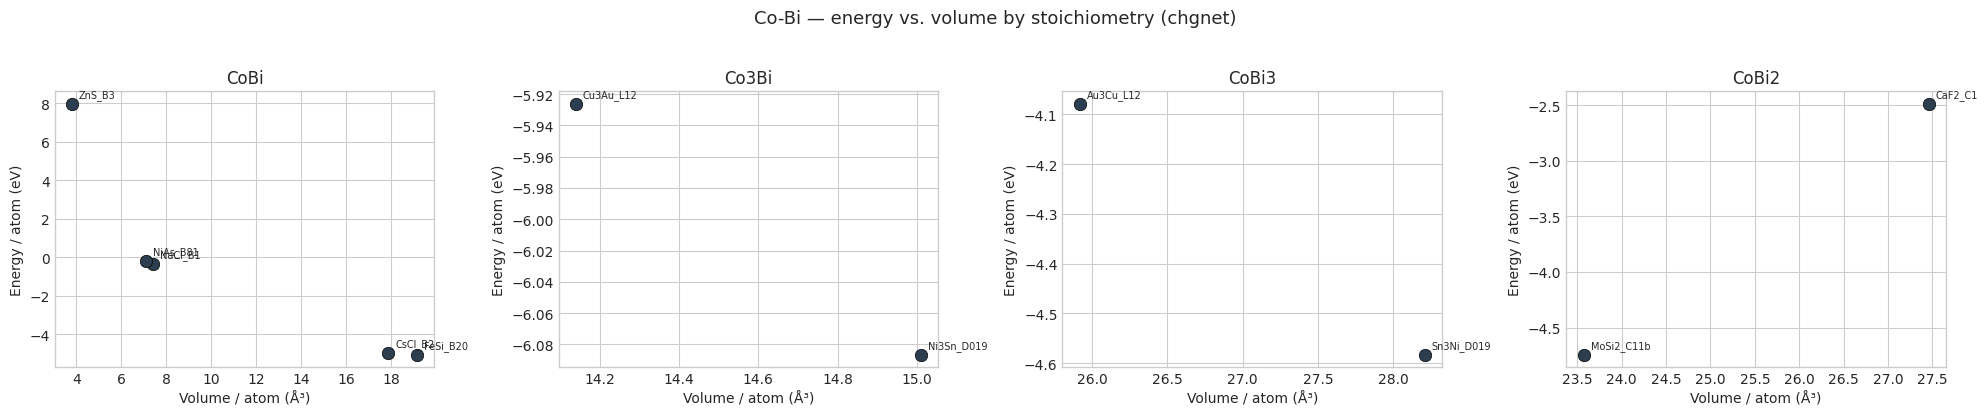

In [26]:
stoich_groups = ok.groupby("formula").filter(lambda g: len(g) >= 2)

if stoich_groups.empty:
    print("Need at least 2 prototypes at the same stoichiometry for this plot.")
else:
    formulas = stoich_groups["formula"].unique()
    n_plots = len(formulas)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), squeeze=False)

    for i, formula in enumerate(formulas):
        ax = axes[0, i]
        sub = ok[ok["formula"] == formula]
        ax.scatter(
            sub["volume_per_atom_A3"], sub["energy_per_atom_eV"],
            s=80, c="#2c3e50", edgecolors="black", linewidths=0.5,
        )
        for _, r in sub.iterrows():
            ax.annotate(
                r["prototype"], (r["volume_per_atom_A3"], r["energy_per_atom_eV"]),
                textcoords="offset points", xytext=(5, 5), fontsize=7,
            )
        ax.set_xlabel("Volume / atom (\u00c5\u00b3)")
        ax.set_ylabel("Energy / atom (eV)")
        ax.set_title(formula)

    fig.suptitle(f"{SYSTEM} — energy vs. volume by stoichiometry ({MODEL})", fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()